# Visualizando o Tempo de Permanência no Pronto-Socorro com PROC BOX

## Resumo Executivo

Uma análise de operações hospitalares que usa PROC BOXPLOT (com o alias PROC BOX) para comparar o tempo de permanência no pronto-socorro entre três serviços clínicos. Diagramas de caixa esquemáticos lado a lado mostram, de relance, a mediana, os quartis, a média e os valores atípicos de longa permanência de cada serviço.

Ao longo de 100 atendimentos simulados, o tempo mediano de permanência aumenta de forma constante de **40.0 horas em Medicine** para **50.4 horas em Surgery** e **60.5 horas em Trauma**, e as médias seguem a mesma ordem (41.6, 54.6, 62.8 horas). Surgery apresenta três valores atípicos altos acima do seu bigode superior (até 84.3 horas) — os casos de espera por leito que consomem o maior número de horas-leito. O notebook desenha a comparação de três maneiras: um diagrama esquemático, uma sobreposição de tendência de médias e um layout horizontal.

## Fontes de Dados

Todos os dados são gerados internamente pela primeira etapa DATA (`call streaminit(20260531)`); nenhuma entrada externa ou de rede é utilizada.

**`ed_los`** — uma linha por atendimento no pronto-socorro (100 linhas)

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `PatientID` | Num | Identificador sequencial do atendimento (1-100) |
| `Department` | Char(12) | Serviço de admissão: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Gravidade da triagem: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Tempo de permanência em horas; uma média determinada pelo serviço e pela gravidade mais ruído normal, com um choque ocasional de longa permanência (rotulado como "Length of Stay (hours)") |

A composição obtida é de 34 atendimentos em Medicine / 36 em Surgery / 30 em Trauma, e 51 Routine / 35 Urgent / 14 Critical por gravidade de triagem.

# Visualizando o Tempo de Permanência no Pronto-Socorro com PROC BOX

O tempo de permanência (LOS) é uma das métricas operacionais mais acompanhadas em um pronto-socorro hospitalar: ele determina a disponibilidade de leitos, a alocação de pessoal, o fluxo de pacientes e os indicadores de qualidade. As médias sozinhas escondem a história — o que importa para uma equipe de operações é a *dispersão* das permanências, os *valores atípicos* que imobilizam recursos e como as distribuições diferem entre os serviços clínicos.

PROC BOX (um alias para PROC BOXPLOT) foi criado exatamente para esse tipo de comparação. Ele desenha diagramas de caixa e bigode lado a lado, marcando a mediana, os quartis, a média e as observações extremas de cada grupo, de modo que um analista consiga ler o formato da distribuição de LOS de cada serviço de relance.

Neste notebook, nós:

1. Geramos um conjunto de dados sintético de atendimentos de pronto-socorro que se ajusta ao ambiente de 100 observações.
2. Produzimos um diagrama de caixa esquemático de LOS por departamento, com a tabela de estatísticas correspondente.
3. Sobrepomos uma linha de tendência de médias com `BOXCONNECT=MEAN` para tornar explícito o gradiente entre serviços.
4. Redesenhamos a mesma comparação horizontalmente com `HORIZONTAL`.

## Etapa 1 — Gerar dados sintéticos de atendimentos do pronto-socorro

Simulamos 100 atendimentos de pronto-socorro. Cada paciente é atribuído a um de três serviços clínicos (Medicine, Surgery, Trauma) e a uma gravidade de triagem (Routine, Urgent, Critical). O tempo de permanência é construído a partir de uma linha de base específica do serviço, deslocada para cima para pacientes de maior gravidade, com ruído normalmente distribuído. Uma pequena fração dos atendimentos recebe um choque adicional de longa permanência para imitar a cauda direita pesada que os dados reais de pronto-socorro sempre apresentam (espera por leito, admissões aguardando um leito de internação). A semente fixa em `call streaminit` torna o conjunto de dados totalmente reproduzível.

In [1]:
OPÇÕES linesize=96;

DADOS ed_los;
   CHAMAR streaminit(20260531);
   COMPRIMENTO Department $ 12 Severity $ 10;
   FAZER PatientID = 1 ATÉ 100;
      d = rand('integer', 1, 3);
      SE d = 1 ENTÃO Department = "Medicina";
      SENÃO SE d = 2 ENTÃO Department = "Cirurgia";
      SENÃO Department = "Trauma";

      u = rand('uniform');
      SE u < 0.55 ENTÃO s = 1;
      SENÃO SE u < 0.85 ENTÃO s = 2;
      SENÃO s = 3;
      SE s = 1 ENTÃO Severity = "Rotina";
      SENÃO SE s = 2 ENTÃO Severity = "Urgente";
      SENÃO Severity = "Crítico";

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      SE rand('uniform') < 0.06 ENTÃO
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      SE LOS_Hours < 2 ENTÃO LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      SAÍDA;
   FIM;
   REMOVER d u s BASE;
   RÓTULO Department = "Departamento"
          Severity = "Gravidade"
          LOS_Hours = "Tempo de Permanência (horas)";
EXECUTAR;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Etapa 2 — Ordenar pela variável de grupo

PROC BOX espera que a variável de grupo (eixo horizontal) esteja ordenada, de modo que as observações de cada grupo fiquem contíguas. Ordenamos por `Department` antes de plotar.

In [2]:
PROCEDIMENTO ORDENAR DADOS=ed_los;
   POR Department;
EXECUTAR;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Etapa 3 — Diagrama de caixa esquemático

A análise central. A sintaxe `PLOT analysis-var * group-var` solicita uma caixa por departamento. `BOXSTYLE=SCHEMATIC` produz um diagrama esquemático clássico de Tukey: os bigodes se estendem até as observações mais extremas dentro de 1.5 vez o intervalo interquartílico, e quaisquer pontos além disso são desenhados individualmente como valores atípicos — ideal para identificar os casos de longa permanência que sobrecarregam a capacidade.

`NOHLABEL` suprime o rótulo redundante do eixo horizontal, já que os nomes dos departamentos são autoexplicativos. Ao lado do diagrama, PROC BOXPLOT imprime uma tabela de estatísticas com o N, o mínimo, os quartis, a mediana, o máximo, a média e o desvio padrão de cada departamento.

                    Tempo de Permanência no Pronto-Socorro por Departamento                     

                    Tempo de Permanência no Pronto-Socorro por Departamento

                                     The BOXPLOT Procedure

Schematic Plots for Tempo de Permanência (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Tempo de Permanência no Pronto-Socorro por Departamento.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


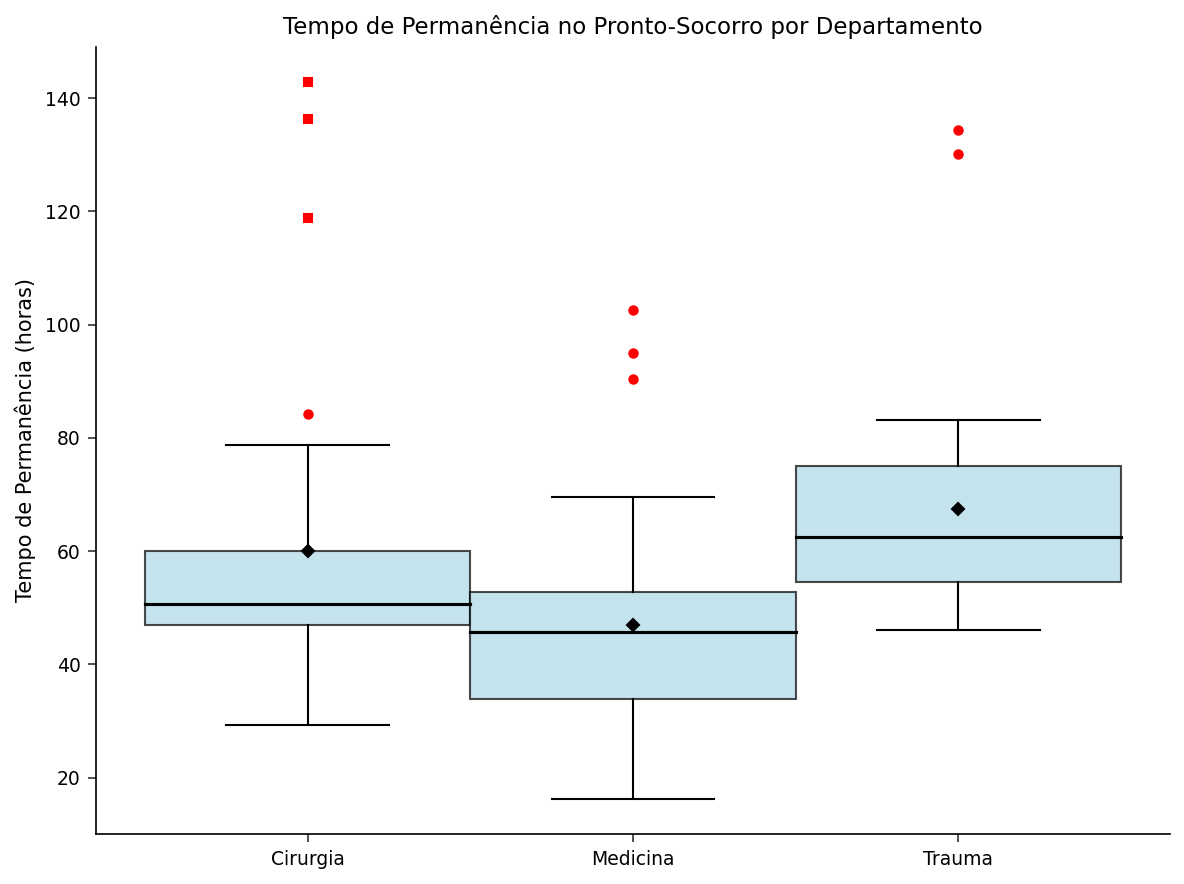

In [3]:
TÍTULO "Tempo de Permanência no Pronto-Socorro por Departamento";
PROCEDIMENTO boxplot DADOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
EXECUTAR;

## Etapa 4 — Sobrepor uma linha de tendência de médias

Para tornar explícito o gradiente de serviço para serviço, adicionamos `BOXCONNECT=MEAN`. PROC BOXPLOT então desenha uma linha conectando a média de cada caixa (os marcadores em losango), transformando as três distribuições separadas em uma única tendência legível. Como os departamentos estão ordenados Medicine → Surgery → Trauma, a linha de conexão ascendente resume o aumento no tempo médio de permanência em um só traço — uma indicação útil para um painel de operações.

         Tempo de Permanência no Pronto-Socorro por Departamento — Tendência de Médias          

       Tempo de Permanência no Pronto-Socorro por Departamento — Tendência de Médias

                                     The BOXPLOT Procedure

Schematic Plots for Tempo de Permanência (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Tempo de Permanência no Pronto-Socorro por Departamento — Tendência de Médias.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


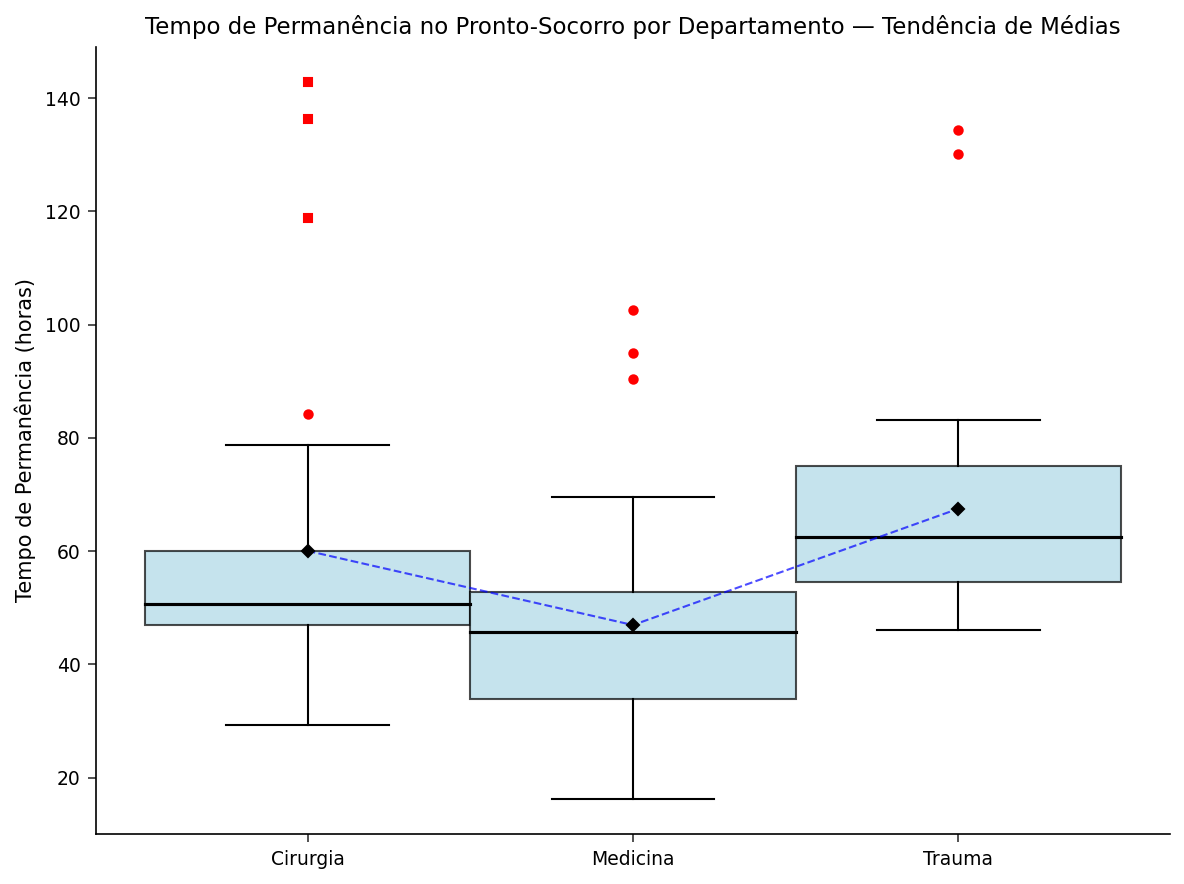

In [4]:
TÍTULO "Tempo de Permanência no Pronto-Socorro por Departamento — Tendência de Médias";
PROCEDIMENTO boxplot DADOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
EXECUTAR;

## Etapa 5 — Layout horizontal

A mesma comparação se lê naturalmente de lado. Adicionar `HORIZONTAL` inverte os eixos, de modo que as caixas correm da esquerda para a direita com a resposta no eixo x — um layout que escala melhor quando os nomes dos serviços são longos ou numerosos, e que muitos painéis de operações preferem. As estatísticas são idênticas às da visão vertical; apenas a orientação muda.

              Tempo de Permanência no Pronto-Socorro por Departamento — Horizontal              

            Tempo de Permanência no Pronto-Socorro por Departamento — Horizontal

                                     The BOXPLOT Procedure

Schematic Plots for Tempo de Permanência (horas)

Departamento          N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Cirurgia             36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Tempo de Permanência no Pronto-Socorro por Departamento — Horizontal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


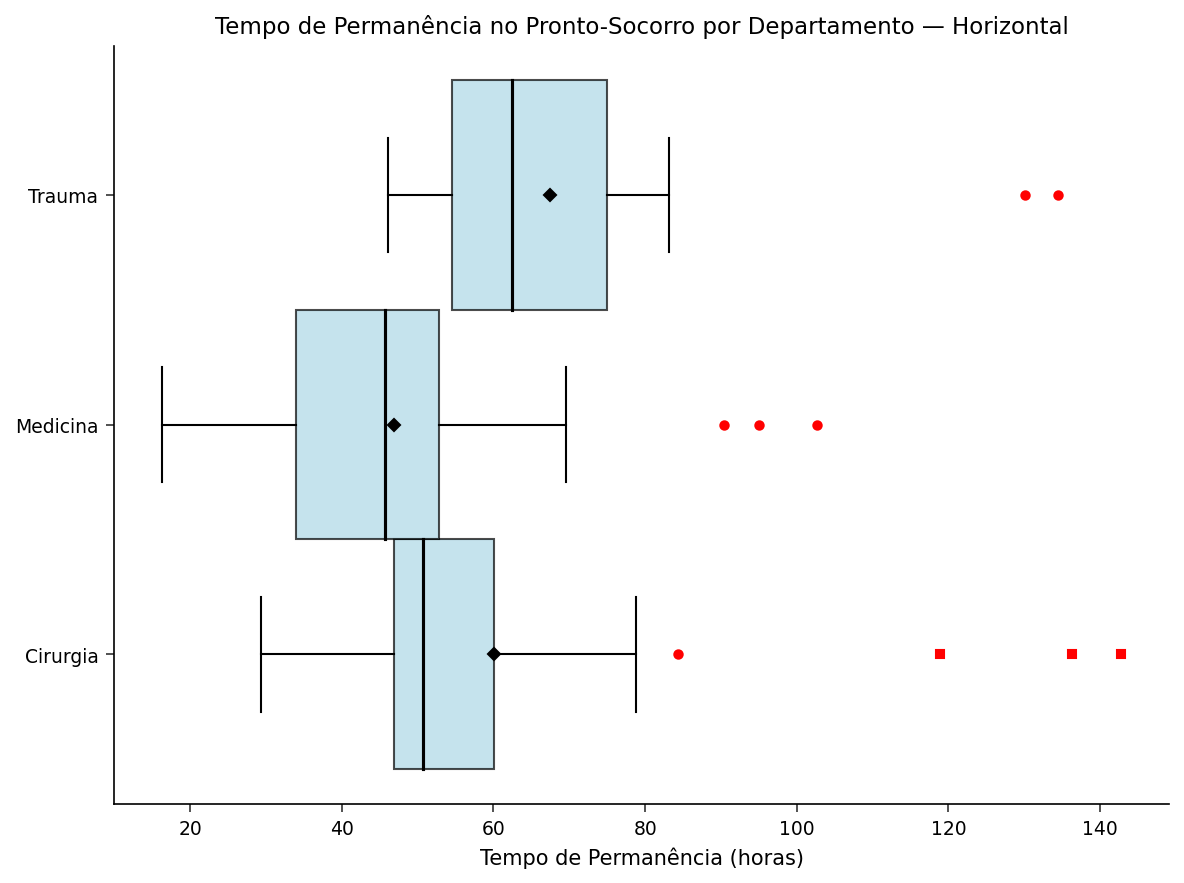

In [5]:
TÍTULO "Tempo de Permanência no Pronto-Socorro por Departamento — Horizontal";
PROCEDIMENTO boxplot DADOS=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
EXECUTAR;

## Interpretando os resultados

Os diagramas de caixa e a tabela de estatísticas correspondente traduzem os dados brutos de LOS em um quadro operacionalmente acionável:

- **Um gradiente de serviço claro.** O tempo mediano de permanência aumenta monotonicamente entre os três serviços: **Medicine 40.0 h → Surgery 50.4 h → Trauma 60.5 h**. As médias contam a mesma história (41.6, 54.6, 62.8 h), e a linha `BOXCONNECT=MEAN` na Etapa 4 desenha esse aumento como uma única tendência ascendente. Os pacientes de Trauma permanecem, em média, cerca de 50% mais tempo que os pacientes de Medicine.

- **A variabilidade importa tanto quanto a mediana.** O intervalo interquartílico (a altura da caixa) é o mais amplo para Medicine (Q1 32.8 h a Q3 51.2 h, uma amplitude de 18.3 horas) e o mais estreito para Trauma (Q1 54.5 h a Q3 68.5 h, uma amplitude de 14.0 horas). Medicine é, portanto, não apenas o serviço mais curto, mas também o menos previsível — a propriedade que complica as previsões de gestão de leitos.

- **Os valores atípicos sinalizam os casos de espera por leito.** Os bigodes esquemáticos param em 1.5 × IQR, de modo que os três pontos vermelhos acima do bigode superior de Surgery (com pico em 84.3 h) se destacam como atendimentos genuínos de longa permanência — exatamente os casos de espera por leito que consomem horas-leito desproporcionais. Medicine e Trauma não apresentam pontos além de seus bigodes nesta amostra.

- **A amplitude conta a história do planejamento de capacidade.** As permanências observadas variam de 16.3–69.5 h em Medicine, 29.3–84.3 h em Surgery e 46.1–83.2 h em Trauma. Trauma nunca produz uma permanência curta (seu mínimo, 46.1 h, excede a mediana de Medicine), o que é o que uma equipe de operações esperaria do serviço mais intensivo em recursos.

Juntas, essas visões dão à liderança de um pronto-socorro uma base defensável e ciente da distribuição para a alocação de pessoal e o planejamento de capacidade — muito mais informativa do que comparar apenas o LOS médio departamental.